# 甲状腺疾病异常检测任务

## 1. 问题的形式化描述
输入：
- 训练集 $D_{train} = \{x_1, x_2, \dots, x_n\}$，其中每个样本 $x_i \in \mathbb{R}^6$。训练集仅包含“正常”样本（标签均为 0）。
- 测试集 $D_{test} = \{(x_j, y_j)\}_{j=1}^m$，其中 $x_j \in \mathbb{R}^6$，$y_j \in \{0, 1\}$。测试集包含正常样本（0）和患病样本（1）。
- 数据集规模：总计 3772 个样本，特征维度为 6 维（已脱敏）。

输出：
- 针对测试集中的每个样本 $x_j$，构建映射函数 $f(x_j) \to \{0, 1\}$，预测其是否患病。

目标：
- 学习训练集中正常样本的分布规律。
- 寻找一个评分函数 $S(x)$ 和阈值 $\tau$。当 $S(x) > \tau$ 时，判定为异常/患病（1）；反之判定为正常（0）。

## 2. 方案设计
### 2.1 数据特点分析与方法选择
   - 这是一个无监督/半监督学习场景的异常检测问题，其中训练集只有正常样本，与正常样本统计规律显著不同的点即为异常点。
   - 方法上选择**孤立森林 (Isolation Forest)**。孤立森林通过随机划分特征来孤立样本。异常点（患病样本）通常在特征空间中分布稀疏且远离正常群体，因此更容易在较短的路径上被孤立。该算法对高维数据鲁棒性好，且不需要假设数据分布。模型在仅包含正常样本的训练集上进行训练，学习正常数据的特征空间分布。

### 2.2 评估指标选择
   - AUC-ROC：衡量模型区分正常与患病样本的整体能力，不受阈值影响。
   - 混淆矩阵：直观展示误诊与漏诊情况。
   - F1-Score / Recall：在医疗场景下，召回率（不漏诊）尤为重要。

## 3 实现模型并训练

### 3.1 数据加载
加载训练集和测试集数据，观察并描述数据特征。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

plt.style.use('seaborn-v0_8')
%matplotlib inline

# 加载数据
train_df = pd.read_csv('train-set.csv')
test_df = pd.read_csv('test-set.csv')
print(f"训练集规模: {train_df.shape}, 测试集规模: {test_df.shape}")


训练集规模: (1839, 6), 测试集规模: (1933, 7)


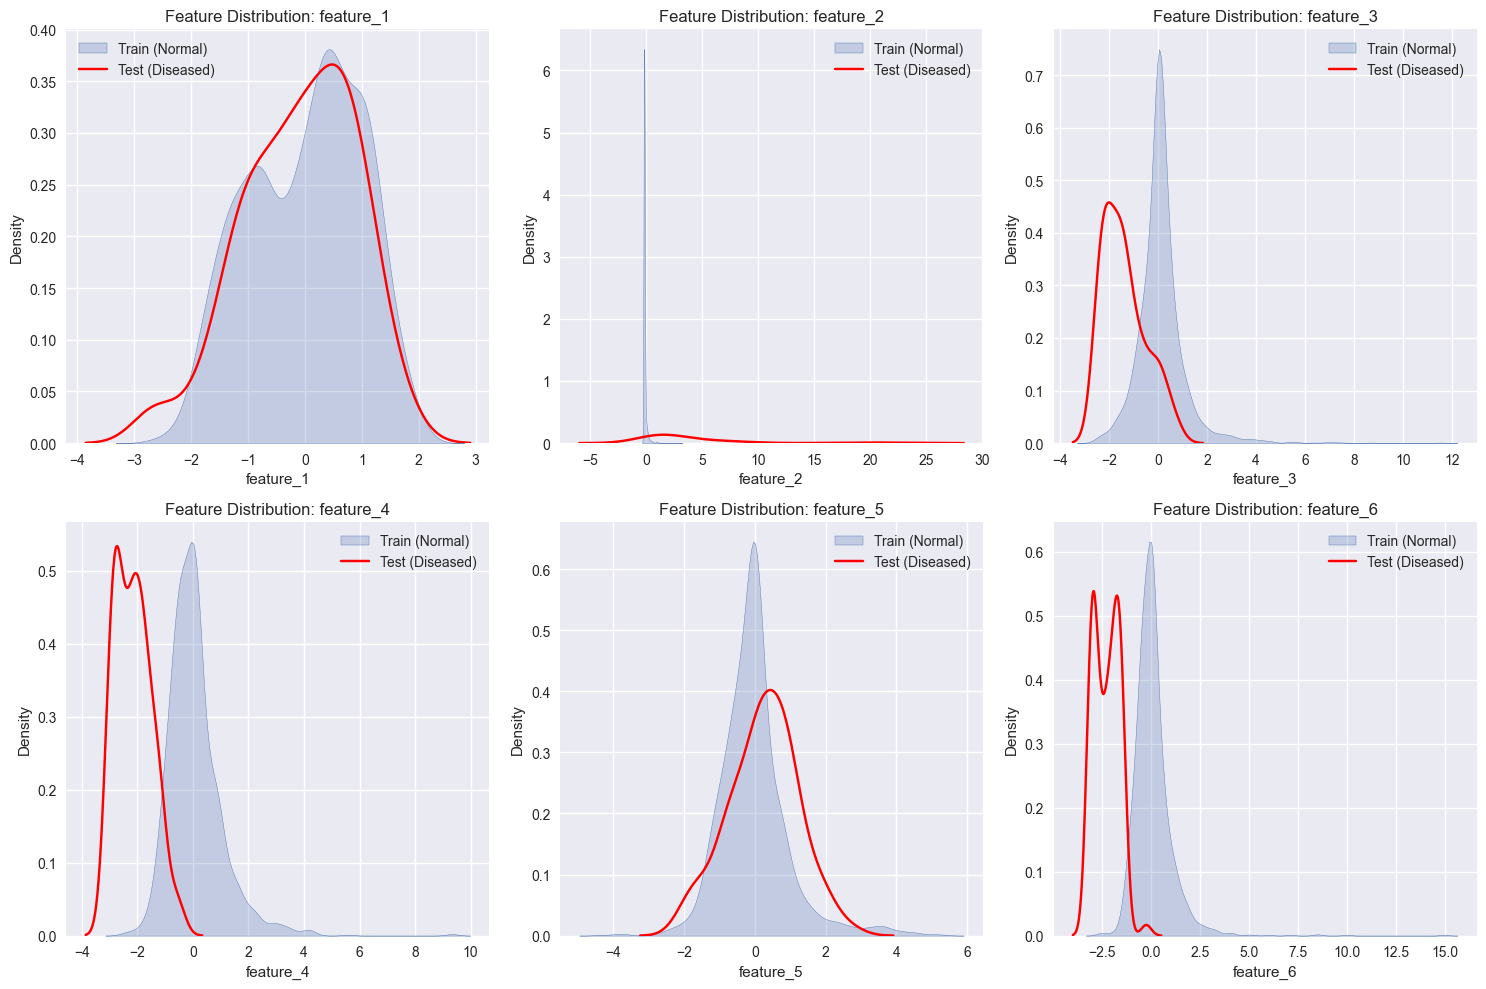

In [2]:
# 提取特征
features = train_df.columns.tolist()

# 绘制特征分布图
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(train_df[col], label='Train (Normal)', fill=True)
    sns.kdeplot(test_df[test_df['label']==1][col], label='Test (Diseased)', color='red')
    plt.title(f'Feature Distribution: {col}')
    plt.legend()
plt.tight_layout()
plt.show()

### 3.2 数据预处理
加载训练集和测试集数据，使用 `StandardScaler` 对 6 维特征进行标准化处理，使模型训练更加稳定。

In [3]:
# 数据预处理
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df.iloc[:, :6])
X_test = scaler.transform(test_df.iloc[:, :6])
y_test = test_df['label']

### 3.3. 模型初始化
选用孤立森林 (Isolation Forest)算法。我们将 `contamination` 参数设为 0.01，考虑到训练集虽然理论上全为正常样本，但可能存在极少量的标注噪声或极端离群点。
### 3.4 模型训练
仅使用包含正常样本的训练集 $D_{train}$ 来学习正常数据的分布规律。

In [4]:
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42) # contamination 设为 0.01 是因为训练集理论上全正常，只需剔除少量潜在噪声

model.fit(X_train)

IsolationForest(contamination=0.01, n_estimators=200, random_state=42)

### 3.5 结果预测
利用训练好的模型对测试集进行评分，计算每个样本的异常程度。评分越高，表示该样本越偏离正常分布，即患病可能性越大。

In [5]:
# 获取决策分数（越高越异常）
test_scores = -model.decision_function(X_test)

# 默认判断，根据 contamination 自动划定阈值
y_pred_default = [1 if x == -1 else 0 for x in model.predict(X_test)]

### 4. 效果评估
为了全面评估模型在测试集上的表现，我们采用以下多维度的评估手段：
1. ROC 曲线与 AUC 值：评估模型在不同阈值下的分类性能。AUC 值越接近 1，说明模型对正常和患病样本的区分能力越强。
2. 混淆矩阵：直观展示模型在默认阈值下的预测结果，包括：
   - True Negatives: 正确预测为正常的样本。
   - False Positives: 误诊（正常预测为患病）。
   - False Negatives: 漏诊（患病预测为正常）。
   - True Positives: 正确预测为患病的样本。
3. 分类报告：计算准确率 Precision、召回率 Recall 和 F1-score。
4. 异常分数分布分析：通过可视化正常样本与患病样本的评分分布，探讨如何通过调整阈值来优化模型效果（例如在医疗场景中提高召回率以减少漏诊）。

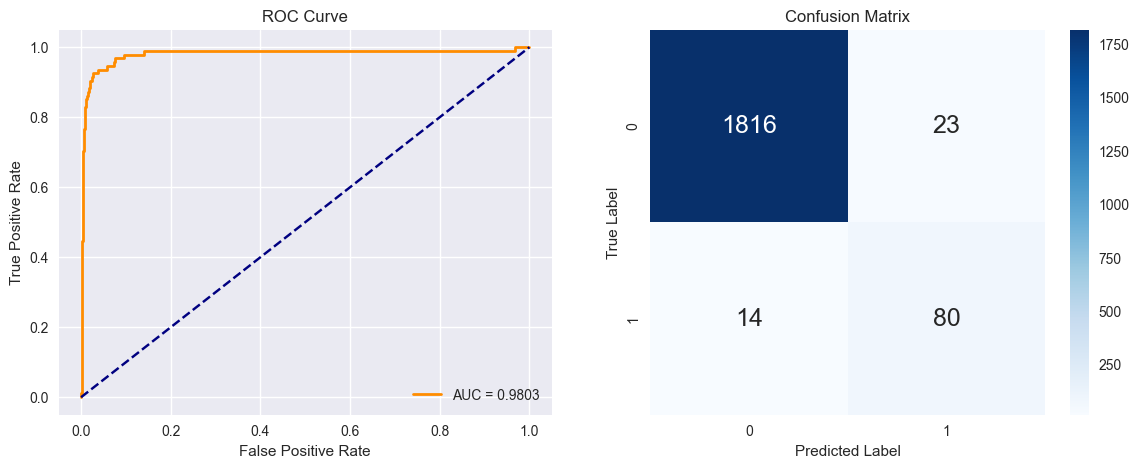

--- 详细分类报告 ---
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1839
         1.0       0.78      0.85      0.81        94

    accuracy                           0.98      1933
   macro avg       0.88      0.92      0.90      1933
weighted avg       0.98      0.98      0.98      1933



In [6]:
# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, test_scores)
auc_val = roc_auc_score(y_test, test_scores)

# 绘图
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC 曲线
ax[0].plot(fpr, tpr, label=f'AUC = {auc_val:.4f}', color='darkorange', lw=2)
ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend()

# 2. 混淆矩阵热力图
cm = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
for t in ax[1].texts:
    t.set_fontsize(18)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_title('Confusion Matrix')

plt.show()

print("--- 详细分类报告 ---")
print(classification_report(y_test, y_pred_default))

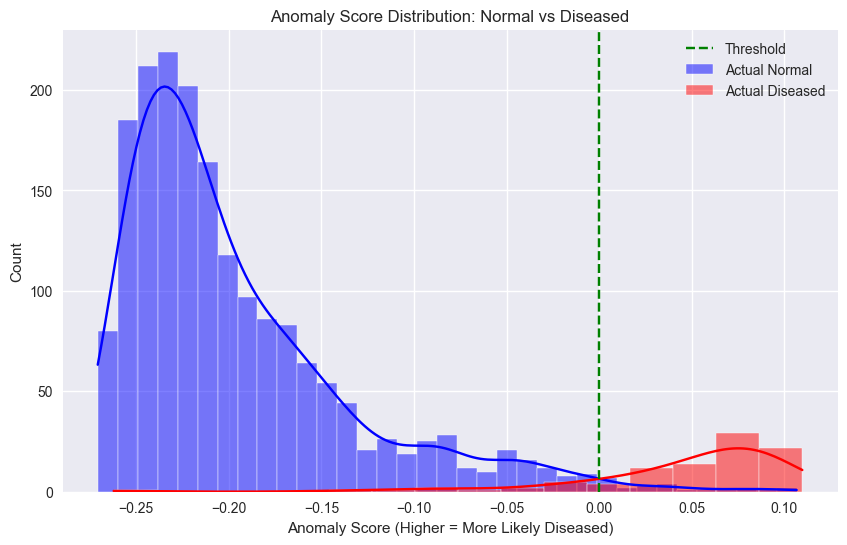

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(test_scores[y_test == 0], label='Actual Normal', color='blue', kde=True, alpha=0.5)
sns.histplot(test_scores[y_test == 1], label='Actual Diseased', color='red',kde=True, alpha=0.5)
plt.axvline(x=0, color='green', linestyle='--', label='Threshold')
plt.title('Anomaly Score Distribution: Normal vs Diseased')
plt.xlabel('Anomaly Score (Higher = More Likely Diseased)')
plt.legend()
plt.show()

## 5. 结果分析与改进方案

### 5.1 结果分析
根据上述输出结果，我们可以得出以下结论：
1. 从 ROC 曲线和 AUC 值可以看出，孤立森林模型在仅使用正常样本训练的情况下，展现出了较强的区分能力。AUC 值较高说明模型能够较好地将患病样本（异常点）与正常样本区分开。
2. 从异常分数分布图可以观察到，正常样本的分数集中在较低区域，而患病样本的分数普遍较高，两者之间存在一定的重叠区域。使用默认阈值 `contamination=0.01` 的模型准确率为 0.78，召回率为 0.85，即约 22% 的误诊率和约 15% 的漏诊率。在甲状腺疾病检测中，漏诊的代价通常高于误诊。因此，在实际应用中，我们可能需要调低判定阈值，以牺牲部分精确率为代价来换取更高的召回率。

### 5.2 可能的改进方案
为了进一步提升模型性能，可以考虑以下方向：
1. 超参数优化：
   - 调整 `n_estimators`（树的数量）和 `max_samples`（每棵树的样本数）以提高模型的稳定性。
   - 细致调整 `contamination` 参数，或根据验证集的 F1-score 手动寻找最优阈值。
2. 尝试其他无监督算法：
   - Local Outlier Factor (LOF：关注局部密度差异，可能对局部异常点更敏感。
   - One-Class SVM：通过寻找超平面来划分正常区域，适合处理非线性分布的数据。
   - Autoencoder (自动编码器)：利用神经网络重构正常样本，重构误差大的点即为异常点。
3. 特征工程：
   - 尽管数据已脱敏，但可以尝试构造多项式特征或进行非线性变换，以增强模型对特征间复杂关系的捕捉能力。
4. 集成学习：
   - 将多种异常检测算法的结果进行集成（如取平均分或投票），以降低单一模型的偏差。